# 📊 Feature Prioritization Tool

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/mini-saas-products/feature-prioritizer/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=mini-saas-products/feature-prioritizer/demo.ipynb)

> **We argue about priorities without data.** RICE turns "I feel like we should build X" into a number you can rank and defend. Reach × Impact × Confidence ÷ Effort.

**This notebook covers:**
1. The RICE formula and its scales
2. Scoring a backlog
3. Ranking + the value/effort quadrant
4. A ranked bar chart
5. Try your own backlog


## Step 1 — RICE

$$RICE = \frac{Reach \times Impact \times Confidence}{Effort}$$

- **Reach** — how many users/events per quarter this touches.
- **Impact** — how much it moves the needle, on a fixed scale: massive=3, high=2, medium=1, low=0.5, minimal=0.25.
- **Confidence** — % how sure you are (0-100). This is the honesty knob — a huge-reach idea you can't back with data gets discounted.
- **Effort** — person-months. It's the denominator, so cheap wins float up.

The point isn't precision — it's a *shared, explicit* scale so debate is about the inputs, not egos.


In [1]:
from __future__ import annotations

import statistics
from dataclasses import dataclass
from typing import List

IMPACT_SCALE = {"massive": 3.0, "high": 2.0, "medium": 1.0, "low": 0.5, "minimal": 0.25}


@dataclass
class Feature:
    name: str
    reach: float
    impact: float
    confidence: float   # percent
    effort: float       # person-months


def rice(f: Feature) -> float:
    return 0.0 if f.effort <= 0 else (f.reach * f.impact * (f.confidence / 100)) / f.effort


demo = Feature("Two-factor auth", reach=5000, impact=2.0, confidence=90, effort=2)
print(f"{demo.name}: RICE = (5000 x 2 x 0.90) / 2 = {rice(demo):.0f}")


Two-factor auth: RICE = (5000 x 2 x 0.90) / 2 = 4500


## Step 2 — Score a backlog

Eight candidate features. Note how the mobile app — huge reach and massive impact — is dragged down by 12 person-months of effort and only 60% confidence, while cheap high-confidence wins rise.


In [2]:
backlog = [
    Feature("Dark mode", 8000, 1.0, 90, 2),
    Feature("SSO / SAML login", 1500, 2.0, 80, 3),
    Feature("Mobile app", 12000, 3.0, 60, 12),
    Feature("CSV export", 3000, 1.0, 100, 1),
    Feature("AI recommendations", 10000, 2.0, 50, 8),
    Feature("Two-factor auth", 5000, 2.0, 90, 2),
    Feature("Custom themes", 2000, 0.5, 80, 4),
    Feature("Slack integration", 4000, 1.0, 85, 2),
]
ranked = sorted(backlog, key=rice, reverse=True)
for i, f in enumerate(ranked, 1):
    print(f"{i}. {f.name:20} RICE {rice(f):7.0f}")


1. Two-factor auth      RICE    4500
2. Dark mode            RICE    3600
3. CSV export           RICE    3000
4. Mobile app           RICE    1800
5. Slack integration    RICE    1700
6. AI recommendations   RICE    1250
7. SSO / SAML login     RICE     800
8. Custom themes        RICE     200


## Step 3 — Value/effort quadrant

RICE gives a single ranking, but a 2×2 shows *why*. Value proxy = Reach × Impact × Confidence (the RICE numerator). Split at the medians: **Quick wins** (high value, low effort) go first; **Time sinks** (low value, high effort) get killed.


In [3]:
def quadrant(f, val_med, eff_med):
    val = f.reach * f.impact * (f.confidence / 100)
    high_val, low_eff = val >= val_med, f.effort < eff_med
    if high_val and low_eff: return "Quick win"
    if high_val: return "Big bet"
    if low_eff: return "Fill-in"
    return "Time sink"


values = [f.reach * f.impact * (f.confidence / 100) for f in backlog]
val_med, eff_med = statistics.median(values), statistics.median([f.effort for f in backlog])
for f in ranked:
    print(f"{f.name:20} -> {quadrant(f, val_med, eff_med)}")


Two-factor auth      -> Quick win
Dark mode            -> Quick win
CSV export           -> Fill-in
Mobile app           -> Big bet
Slack integration    -> Fill-in
AI recommendations   -> Big bet
SSO / SAML login     -> Time sink
Custom themes        -> Time sink


## Step 4 — Visualize the ranking

The chart that ends the meeting.


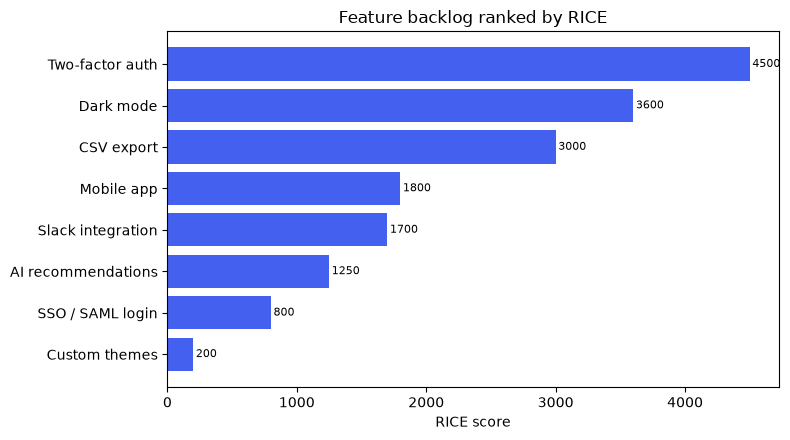

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt

names = [f.name for f in ranked][::-1]
scores = [rice(f) for f in ranked][::-1]
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(names, scores, color="#4361ee")
ax.set_xlabel("RICE score")
ax.set_title("Feature backlog ranked by RICE")
for i, s in enumerate(scores):
    ax.text(s + 20, i, f"{s:.0f}", va="center", fontsize=8)
plt.tight_layout()
plt.savefig("rice_ranking.png", dpi=150, bbox_inches="tight")
plt.show()


## Summary

- **RICE makes priorities defensible.** A number beats "I feel strongly" in a roadmap debate.
- **Effort is the great equalizer.** Big-reach ideas with big effort and shaky confidence rarely top the list — as they shouldn't.
- **Quadrants add the why.** Ship quick wins now, schedule big bets deliberately, kill time sinks.

The full app lets the team edit the backlog live, re-rank instantly, and (with a Claude key) auto-estimate RICE inputs from a plain-English feature description.


## Try your own backlog

Replace the features with your real candidates. The hardest input is Confidence — be honest, and let low confidence be a prompt to go get data before committing.


In [5]:
# my_backlog = [
#     Feature("Feature A", reach=6000, impact=2.0, confidence=70, effort=3),
#     Feature("Feature B", reach=1000, impact=3.0, confidence=90, effort=1),
# ]
# for i, f in enumerate(sorted(my_backlog, key=rice, reverse=True), 1):
#     print(i, f.name, round(rice(f)))


---
Part of **[Phoebe's FDE Portfolio](https://github.com/phoebefu6/phoebe-the-builder)** — Day 53, Mini SaaS Products.

For the interactive Streamlit version (editable backlog, RICE bar chart, value/effort scatter, Claude auto-estimate):
```bash
pip install -r requirements.txt
streamlit run app.py
```
